Question 01

TLS line for first dataset:
Slope (m) = 1.2206658510839083
Intercept (c) = -5.9871645218487535


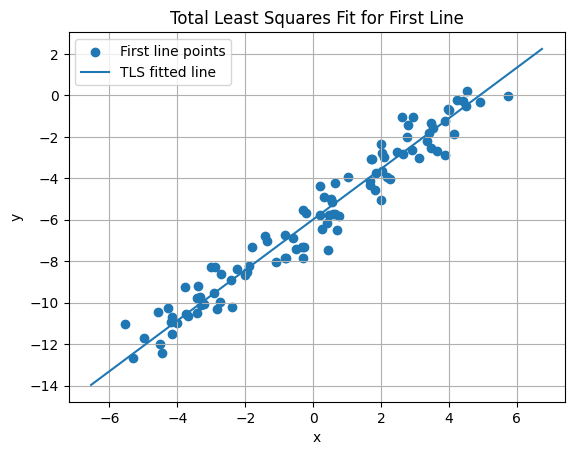

In [ ]:
#Question 1 part (a)

import numpy as np
import matplotlib.pyplot as plt

# Load data
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

# First line only
x1 = D[:, 0]
y1 = D[:, 3]

# Stack points
P = np.column_stack((x1, y1))

# Compute centroid
centroid = np.mean(P, axis=0)

# Center the points
P_centered = P - centroid

# SVD for Total Least Squares
U, S, Vt = np.linalg.svd(P_centered)

# Direction vector of the line
direction = Vt[0]

# Convert to slope-intercept form: y = mx + c
m = direction[1] / direction[0]
c = centroid[1] - m * centroid[0]

print("TLS line for first dataset:")
print("Slope (m) =", m)
print("Intercept (c) =", c)

# Plot
x_plot = np.linspace(min(x1)-1, max(x1)+1, 100)
y_plot = m * x_plot + c

plt.scatter(x1, y1, label="First line points")
plt.plot(x_plot, y_plot, label="TLS fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Total Least Squares Fit for First Line")
plt.grid(True)
plt.show()





Line 1: y = -0.5105x + 1.8902
Line 2: y = 1.0575x + 0.9196
Line 3: y = -0.4961x + 2.3827


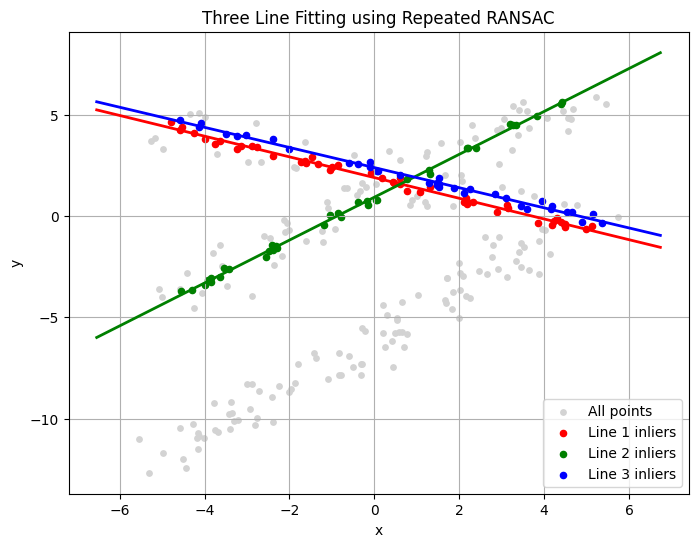

In [ ]:
#Question 1 part (b)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression

# Load dataset
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

# Separate x and y columns
X_cols = D[:, :3]
Y_cols = D[:, 3:]

# Flatten all points into one set
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

# Keep remaining points for repeated RANSAC
X_remain = X_all.copy()
Y_remain = Y_all.copy()

# For plotting
colors = ['red', 'green', 'blue']
line_params = []

plt.figure(figsize=(8, 6))
plt.scatter(X_all, Y_all, color='lightgray', s=15, label='All points')

for i in range(3):
    # Reshape x for sklearn
    X = X_remain.reshape(-1, 1)
    y = Y_remain
    # Fit RANSAC
    ransac = RANSACRegressor(
        estimator=LinearRegression(),
        min_samples=2,
        residual_threshold=0.3,
        max_trials=1000,
        random_state=42 
    )
    ransac.fit(X, y)
    # Inlier and outlier masks
    inlier_mask = ransac.inlier_mask_
    outlier_mask = ~inlier_mask
    # Get fitted line parameters
    m = ransac.estimator_.coef_[0]
    c = ransac.estimator_.intercept_
    line_params.append((m, c))
    
    print(f"Line {i+1}: y = {m:.4f}x + {c:.4f}")

    # Plot inlier points
    plt.scatter(X_remain[inlier_mask], Y_remain[inlier_mask],
                color=colors[i], s=20, label=f'Line {i+1} inliers')

    # Plot fitted line
    x_plot = np.linspace(X_all.min() - 1, X_all.max() + 1, 100)
    y_plot = m * x_plot + c
    plt.plot(x_plot, y_plot, color=colors[i], linewidth=2)

    # Remove inliers and continue with remaining points
    X_remain = X_remain[outlier_mask]
    Y_remain = Y_remain[outlier_mask]

plt.xlabel("x")
plt.ylabel("y")
plt.title("Three Line Fitting using Repeated RANSAC")
plt.legend()
plt.grid(True)
plt.show()